# Survival Model Pipeline

Input:
- The preprocessed `joined_dataset.csv`, which contains monthly business observations with license categories, nearby 311 complaint counts, and location-cluster features.

Processing steps:
- Builds a survival-analysis panel, cleans redundant or non-model columns, standardizes predictors, and fits a penalized time-varying Cox model to study how business, complaint, and location factors relate to closure hazard over time.
- Fits simpler standard Cox model at the business level to estimate user-facing survival probabilities for hypothetical businesses over 1-, 3-, 5-, and 10-year horizons.

Output:
- Fitted Cox model summaries, coefficient plots, location-based risk visualizations, interpretable feature mappings using lookup tables, and saved model artifacts that can later be loaded into a Streamlit app for prediction.



### 1. Setup and load the joined dataset

In [39]:
#!pip install lifelines pandas numpy matplotlib

In [54]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pickle

from sklearn.feature_selection import VarianceThreshold
from sklearn.preprocessing import StandardScaler
from lifelines import CoxTimeVaryingFitter

### 2. Mount Google Drive

In [55]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


### 3. Load joined dataset from Drive

In [56]:
DATA_PATH = "/content/drive/MyDrive/joined_dataset.csv"

joined = pd.read_csv(DATA_PATH)
joined["month"] = pd.to_datetime(joined["month"])

print("Shape:", joined.shape)
print("Unique businesses:", joined["business_id"].nunique())
joined.head()

Shape: (2241432, 236)
Unique businesses: 18546


,business_id,month,active_license_count,business_category_0,business_category_1,business_category_2,business_category_3,business_category_4,business_category_5,business_category_6,...,complaint_type_174,complaint_type_175,complaint_type_176,open,months_since_first_license,location_cluster,business_category_sum,complaint_sum,location_cluster_lat,location_cluster_lng
0,BA-1007652-2022,2025-05-01,1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1,0,24,1.0,2.0,40.746573,-73.895733
1,BA-1007652-2022,2025-06-01,1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1,1,24,1.0,3.0,40.746573,-73.895733
2,BA-1007652-2022,2025-07-01,1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1,2,24,1.0,2.0,40.746573,-73.895733
3,BA-1007652-2022,2025-08-01,1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1,3,24,1.0,3.0,40.746573,-73.895733
4,BA-1007652-2022,2025-09-01,1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1,4,24,1.0,0.0,40.746573,-73.895733


### 4. Check missing values

In [57]:
missing_counts = joined.isna().sum()
missing_cols = missing_counts[missing_counts > 0]

if len(missing_cols) == 0:
    print("No missing values found.")
else:
    print("Columns with missing values:")
    print(missing_cols.sort_values(ascending=False))

print("Total missing values:", joined.isna().sum().sum())

No missing values found.
Total missing values: 0


### 5. Build time-varying survival panel

This step creates a time-varying survival dataset by splitting each business’s timeline into monthly intervals with defined start and stop times. It also labels whether a closure event occurs during each interval, enabling the data to be used in survival analysis models such as a Cox model.

A closure event is assigned when a business’s last observed month in the dataset occurs before the overall final month across all businesses in the panel.

In [97]:
panel = joined.sort_values(["business_id", "month"]).copy()

panel["start"] = panel["months_since_first_license"] - 1
panel["stop"] = panel["months_since_first_license"]

last_month_overall = panel["month"].max()
print(last_month_overall)
last_month_by_business = panel.groupby("business_id")["month"].transform("max")

panel["event"] = (
    (panel["month"] == last_month_by_business) &
    (panel["month"] < last_month_overall)
).astype(int)

panel.head()

2100-12-01 00:00:00


,business_id,month,active_license_count,business_category_0,business_category_1,business_category_2,business_category_3,business_category_4,business_category_5,business_category_6,...,open,months_since_first_license,location_cluster,business_category_sum,complaint_sum,location_cluster_lat,location_cluster_lng,start,stop,event
0,BA-1007652-2022,2025-05-01,1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,1,0,24,1.0,2.0,40.746573,-73.895733,-1,0,0
1,BA-1007652-2022,2025-06-01,1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,1,1,24,1.0,3.0,40.746573,-73.895733,0,1,0
2,BA-1007652-2022,2025-07-01,1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,1,2,24,1.0,2.0,40.746573,-73.895733,1,2,0
3,BA-1007652-2022,2025-08-01,1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,1,3,24,1.0,3.0,40.746573,-73.895733,2,3,0
4,BA-1007652-2022,2025-09-01,1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,1,4,24,1.0,0.0,40.746573,-73.895733,3,4,0


### 6. Drop redundace and non-model columns

- open: redundant indicator
- business_category_sum: intermediate validation column used to check category encoding
- complaint_sum: intermediate check ensuring complaint features summed correctly
- total_311: redundant after individual complaint-type features are included
- location_cluster: cluster identifier not needed after including raw latitude and longitude coordinates
- months_since_first_license: replaced by survival interval variables start and stop

In [59]:
panel = panel.drop(
    columns=[
        "open",
        "business_category_sum",
        "complaint_sum",
        "total_311",
        "location_cluster",
        "months_since_first_license",
    ],
    errors="ignore",
).copy()

### 7. Define feature columns

In [60]:
exclude_cols = ["business_id", "month", "start", "stop", "event"]

feature_cols = [c for c in panel.columns if c not in exclude_cols]

print("Number of candidate features:", len(feature_cols))
print(feature_cols[:20])

Number of candidate features: 228
['active_license_count', 'business_category_0', 'business_category_1', 'business_category_2', 'business_category_3', 'business_category_4', 'business_category_5', 'business_category_6', 'business_category_7', 'business_category_8', 'business_category_9', 'business_category_10', 'business_category_11', 'business_category_12', 'business_category_13', 'business_category_14', 'business_category_15', 'business_category_16', 'business_category_17', 'business_category_18']


### 8. Remove near-constant columns

Eliminates features with extremely low variance to improve model stability and efficiency.

In [61]:
X = panel[feature_cols].copy()

selector = VarianceThreshold(threshold=1e-8)
X_reduced = selector.fit_transform(X)

kept_cols = X.columns[selector.get_support()].tolist()
dropped_low_variance = [c for c in X.columns if c not in kept_cols]

print("Kept features:", len(kept_cols))
print("Dropped near-constant features:", len(dropped_low_variance))

if dropped_low_variance:
    print("Example dropped columns:", dropped_low_variance[:20])

Kept features: 217
Dropped near-constant features: 11
Example dropped columns: ['business_category_16', 'business_category_19', 'business_category_26', 'business_category_31', 'business_category_38', 'business_category_39', 'business_category_44', 'business_category_47', 'complaint_type_20', 'complaint_type_22', 'complaint_type_150']


### 9. Standardize predictors

Ensure that features with different scales contribute comparably.

In [62]:
scaler = StandardScaler()

X_scaled = pd.DataFrame(
    scaler.fit_transform(panel[kept_cols]),
    columns=kept_cols,
    index=panel.index,
)

X_scaled.head()

,active_license_count,business_category_0,business_category_1,business_category_2,business_category_3,business_category_4,business_category_5,business_category_6,business_category_7,business_category_8,...,complaint_type_169,complaint_type_170,complaint_type_171,complaint_type_172,complaint_type_173,complaint_type_174,complaint_type_175,complaint_type_176,location_cluster_lat,location_cluster_lng
0,-0.324584,-0.088779,-0.012727,-0.066067,-0.027092,-0.012727,-0.160848,-0.070902,-0.203824,-0.233733,...,-0.006066,-0.047413,-0.02069,-0.011351,-0.044414,-0.003298,-0.001336,-0.008032,0.039061,0.015664
1,-0.324584,-0.088779,-0.012727,-0.066067,-0.027092,-0.012727,-0.160848,-0.070902,-0.203824,-0.233733,...,-0.006066,-0.047413,-0.02069,-0.011351,-0.044414,-0.003298,-0.001336,-0.008032,0.039061,0.015664
2,-0.324584,-0.088779,-0.012727,-0.066067,-0.027092,-0.012727,-0.160848,-0.070902,-0.203824,-0.233733,...,-0.006066,-0.047413,-0.02069,-0.011351,-0.044414,-0.003298,-0.001336,-0.008032,0.039061,0.015664
3,-0.324584,-0.088779,-0.012727,-0.066067,-0.027092,-0.012727,-0.160848,-0.070902,-0.203824,-0.233733,...,-0.006066,-0.047413,-0.02069,-0.011351,-0.044414,-0.003298,-0.001336,-0.008032,0.039061,0.015664
4,-0.324584,-0.088779,-0.012727,-0.066067,-0.027092,-0.012727,-0.160848,-0.070902,-0.203824,-0.233733,...,-0.006066,-0.047413,-0.02069,-0.011351,-0.044414,-0.003298,-0.001336,-0.008032,0.039061,0.015664


### 10. Build final modeling panel

Combines standardized predictors with survival interval data to create the dataset used for model training.

In [63]:
modeling_panel = pd.concat(
    [panel[["business_id", "month", "start", "stop", "event"]], X_scaled],
    axis=1,
).copy()

print("Modeling panel shape:", modeling_panel.shape)
modeling_panel.head()

Modeling panel shape: (2241432, 222)


,business_id,month,start,stop,event,active_license_count,business_category_0,business_category_1,business_category_2,business_category_3,...,complaint_type_169,complaint_type_170,complaint_type_171,complaint_type_172,complaint_type_173,complaint_type_174,complaint_type_175,complaint_type_176,location_cluster_lat,location_cluster_lng
0,BA-1007652-2022,2025-05-01,-1,0,0,-0.324584,-0.088779,-0.012727,-0.066067,-0.027092,...,-0.006066,-0.047413,-0.02069,-0.011351,-0.044414,-0.003298,-0.001336,-0.008032,0.039061,0.015664
1,BA-1007652-2022,2025-06-01,0,1,0,-0.324584,-0.088779,-0.012727,-0.066067,-0.027092,...,-0.006066,-0.047413,-0.02069,-0.011351,-0.044414,-0.003298,-0.001336,-0.008032,0.039061,0.015664
2,BA-1007652-2022,2025-07-01,1,2,0,-0.324584,-0.088779,-0.012727,-0.066067,-0.027092,...,-0.006066,-0.047413,-0.02069,-0.011351,-0.044414,-0.003298,-0.001336,-0.008032,0.039061,0.015664
3,BA-1007652-2022,2025-08-01,2,3,0,-0.324584,-0.088779,-0.012727,-0.066067,-0.027092,...,-0.006066,-0.047413,-0.02069,-0.011351,-0.044414,-0.003298,-0.001336,-0.008032,0.039061,0.015664
4,BA-1007652-2022,2025-09-01,3,4,0,-0.324584,-0.088779,-0.012727,-0.066067,-0.027092,...,-0.006066,-0.047413,-0.02069,-0.011351,-0.044414,-0.003298,-0.001336,-0.008032,0.039061,0.015664


### 11. Fit penalized Cox time-varying model

Fits a Cox proportional hazards model with time-varying covariates to analyze how factors influence the risk of business closure over time.

In [65]:
ctv = CoxTimeVaryingFitter(penalizer=0.1)

fit_panel = modeling_panel.drop(columns=["month"], errors="ignore").copy()

ctv.fit(
    fit_panel,
    id_col="business_id",
    event_col="event",
    start_col="start",
    stop_col="stop",
    show_progress=True,
)

Iteration 1: norm_delta = 4.07e-02, step_size = 0.9500, log_lik = -163714.89681, newton_decrement = 2.22e+02, seconds_since_start = 7.7
Iteration 2: norm_delta = 1.93e-03, step_size = 0.9500, log_lik = -163493.46082, newton_decrement = 5.09e-01, seconds_since_start = 14.9
Iteration 3: norm_delta = 9.66e-05, step_size = 0.9500, log_lik = -163492.95285, newton_decrement = 1.27e-03, seconds_since_start = 22.6
Iteration 4: norm_delta = 5.08e-06, step_size = 1.0000, log_lik = -163492.95157, newton_decrement = 3.19e-06, seconds_since_start = 30.2
Iteration 5: norm_delta = 7.55e-12, step_size = 1.0000, log_lik = -163492.95157, newton_decrement = 7.76e-18, seconds_since_start = 37.6
Convergence completed after 5 iterations.


<lifelines.CoxTimeVaryingFitter: fitted with 2241432 periods, 18546 subjects, 18545 events>

In [66]:
ctv.print_summary()

<lifelines.CoxTimeVaryingFitter: fitted with 2241432 periods, 18546 subjects, 18545 events>
         event col = 'event'
         penalizer = 0.1
number of subjects = 18546
 number of periods = 2241432
  number of events = 18545
partial log-likelihood = -163492.95
  time fit was run = 2026-03-09 07:23:50 UTC

---
                      coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                             
active_license_count -0.02      0.98      0.00           -0.03           -0.02                0.97                0.98
business_category_0  -0.00      1.00      0.00           -0.01            0.00                0.99                1.00
business_category_1   0.00      1.00      0.00           -0.00            0.01                1.00                1.01
business_category_2   0.00      1.00      0.00           -0.00            0.01                1.00                1.01
business_category_3  -0.00      1.00      0.00           -0.01            0.00                1.00                1.00
business_category_4   0.00      1.00      0.00           -0.00            0.01                1.00                1.01
business_category_5   0.00      1.00      0.00            0.00            0.01                1.00                1.01
business_category_6   0.00      1.00      0.00           -0.00            0.01                1.00                1.01
business_category_7  -0.01      0.99      0.00           -0.01           -0.00                0.99                1.00
business_category_8  -0.01      0.99      0.00           -0.01           -0.00                0.99                1.00
business_category_9   0.00      1.00      0.00           -0.00            0.01                1.00                1.01
business_category_10 -0.00      1.00      0.00           -0.00            0.00                1.00                1.00
business_category_11 -0.00      1.00      0.00           -0.01            0.00                0.99                1.00
business_category_12 -0.00      1.00      0.00           -0.00            0.00                1.00                1.00
business_category_13 -0.00      1.00      0.00           -0.01            0.00                0.99                1.00
business_category_14 -0.00      1.00      0.00           -0.01            0.00                0.99                1.00
business_category_15 -0.00      1.00      0.00           -0.01            0.00                0.99                1.00
business_category_17  0.00      1.00      0.00           -0.00            0.00                1.00                1.00
business_category_18 -0.00      1.00      0.00           -0.01           -0.00                0.99                1.00
business_category_20 -0.00      1.00      0.00           -0.00            0.00                1.00                1.00
business_category_21  0.03      1.03      0.00            0.02            0.03                1.02                1.03
business_category_22  0.00      1.00      0.00           -0.00            0.01                1.00                1.01
business_category_23  0.00      1.00      0.00           -0.00            0.00                1.00                1.00
business_category_24  0.00      1.00      0.00           -0.00            0.01                1.00                1.01
business_category_25 -0.00      1.00      0.00           -0.01            0.00                0.99                1.00
business_category_27 -0.00      1.00      0.00           -0.01            0.00                0.99                1.00
business_category_28 -0.01      0.99      0.00           -0.01           -0.00                0.99                1.00
business_category_29  0.01      1.01      0.00            0.00            0.01                1.00                1.01
business_category_30  0.00      1.00      0.00           -0.00            0.00                1.00                1

### 12. Inspect strongest coefficients

In [108]:
summary = ctv.summary.copy()
summary["abs_coef"] = summary["coef"].abs()

top_effects = summary.sort_values("abs_coef", ascending=False).head(5)
top_effects[["coef", "exp(coef)", "se(coef)", "p"]]

,coef,exp(coef),se(coef),p
covariate,,,,
business_category_21,0.027038,1.027407,0.002051,1.059492e-39
active_license_count,-0.024705,0.975598,0.002036,7.088097e-34
business_category_45,-0.007821,0.992209,0.002034,1.204389e-04
business_category_7,-0.007770,0.992260,0.002031,1.307231e-04
business_category_8,-0.006165,0.993854,0.002036,2.458268e-03


### 13. Full coefficient plot

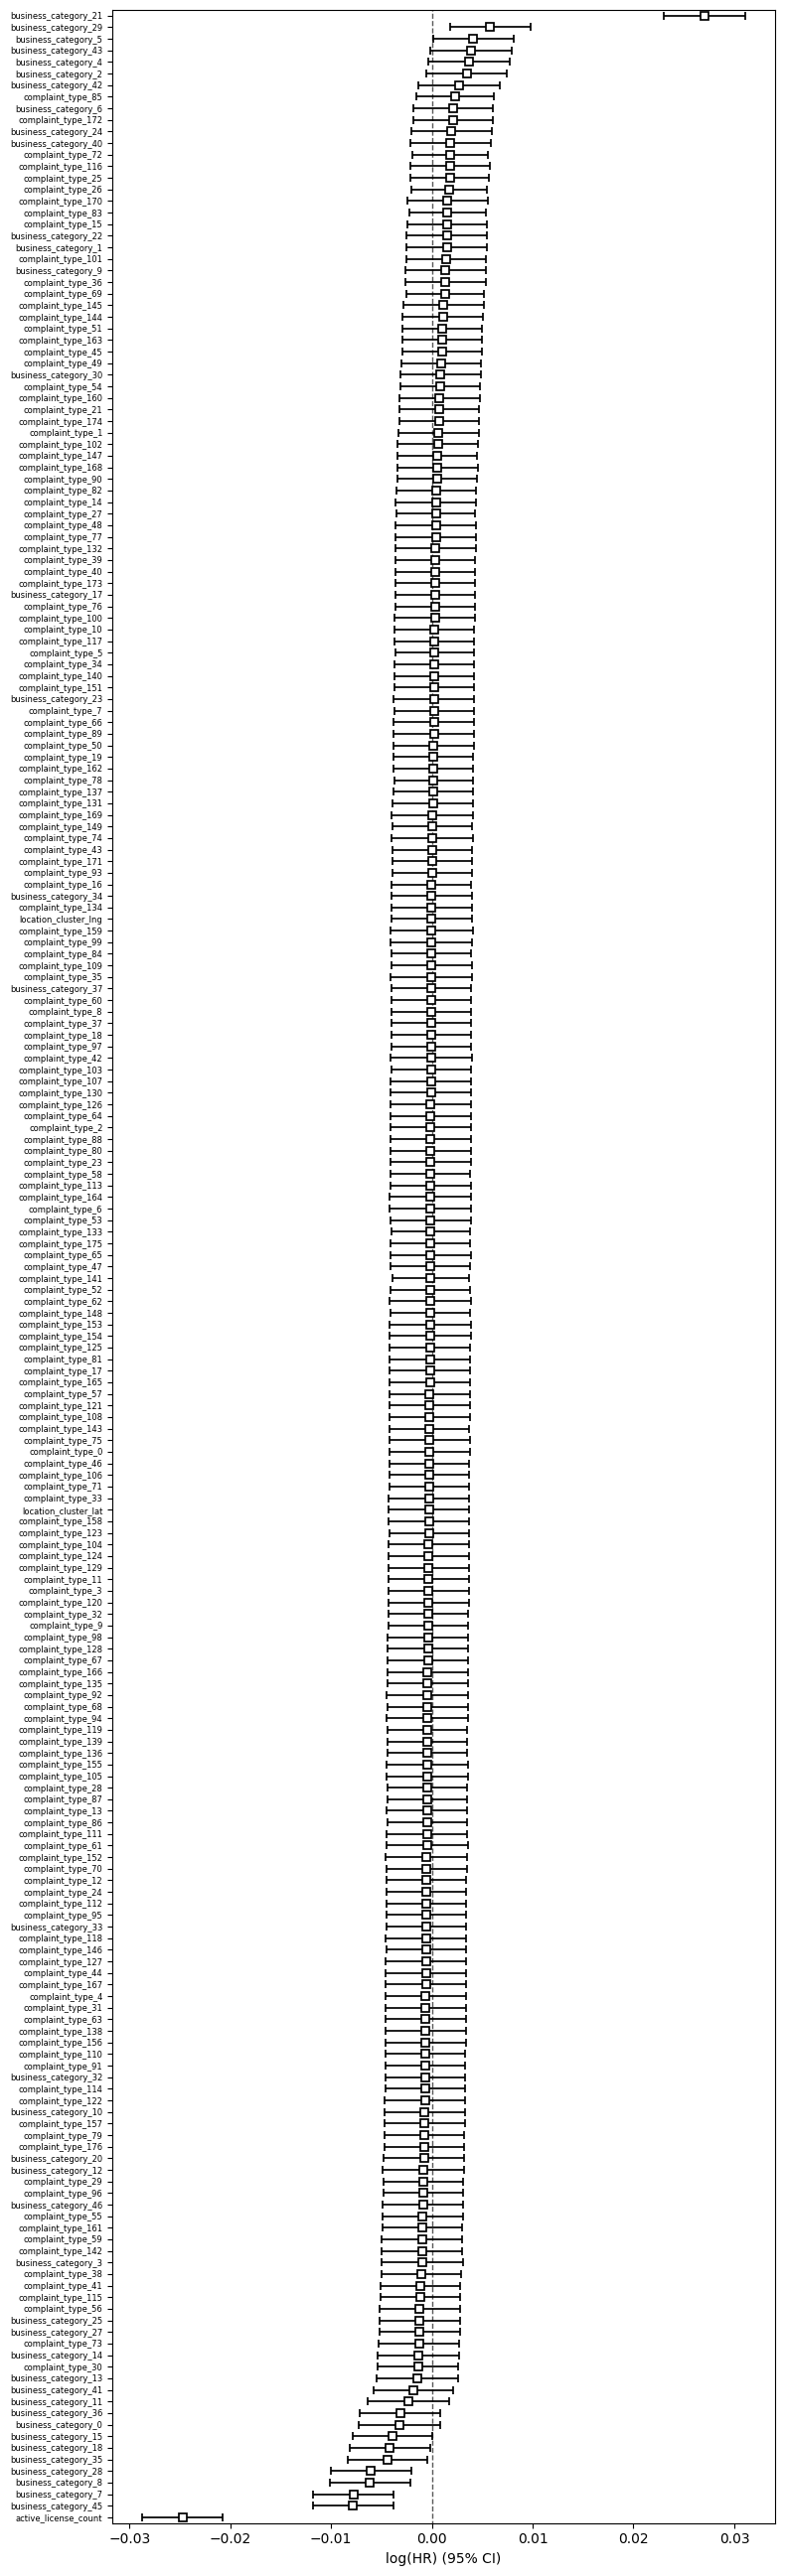

In [104]:
fig, ax = plt.subplots(figsize=(8, max(12, len(ctv.params_) * 0.12)))

ctv.plot(ax=ax)

ax.margins(y=0)

ax.set_ylim(-0.5, len(ctv.params_) - 0.5)

ax.tick_params(axis="y", labelsize=6)

plt.tight_layout()
plt.show()

### 14. Score a hypothetical business-month profile

To generate a prediction for a new business, create a row with the same feature structure as the training data.

In this example, a sample row from the dataset is copied and modified to simulate a new business by specifying the business category, setting complaint counts for different types, and defining the number of active licenses.

After filling in these values, the Cox model predicts the relative hazard of closure by passing the feature columns into `predict_partial_hazard()`, which returns the business's estimated risk relative to the baseline (average business profile in the training data).

In [70]:
example = modeling_panel.iloc[[0]].copy()

business_cat_cols = [c for c in example.columns if c.startswith("business_category_")]
complaint_cols = [c for c in example.columns if c.startswith("complaint_type_")]

if business_cat_cols:
    example.loc[:, business_cat_cols] = 0
    if "business_category_0" in example.columns:
        example["business_category_0"] = 1

if complaint_cols:
    example.loc[:, complaint_cols] = 0
    if "complaint_type_0" in example.columns:
        example["complaint_type_0"] = 5
    if "complaint_type_1" in example.columns:
        example["complaint_type_1"] = 2

if "active_license_count" in example.columns:
    example["active_license_count"] = 1

relative_hazard = ctv.predict_partial_hazard(
    example.drop(columns=["business_id", "month", "start", "stop", "event"], errors="ignore")
)

print("Relative hazard:")
print(relative_hazard)

Relative hazard:
0    0.972717
dtype: float64


In [106]:
example = modeling_panel.iloc[[0]].copy()

# reset category and complaint features
example.loc[:, [c for c in example.columns if c.startswith("business_category_")]] = 0
example.loc[:, [c for c in example.columns if c.startswith("complaint_type_")]] = 0

# set business category
example["business_category_21"] = 1

# set complaint counts
example["complaint_type_0"] = 7
example["complaint_type_2"] = 4
example["complaint_type_5"] = 3

# set license count
example["active_license_count"] = 3

# optional location
example["Latitude"] = 40.7580
example["Longitude"] = -73.9855

relative_hazard = ctv.predict_partial_hazard(
    example.drop(columns=["business_id", "month", "start", "stop", "event"], errors="ignore")
)

print("Relative hazard:")
print(relative_hazard)

Relative hazard:
0    0.952809
dtype: float64


### 15. Save artifacts to Drive

In [71]:
OUTPUT_DIR = "/content/drive/MyDrive/cox_outputs"

import os
os.makedirs(OUTPUT_DIR, exist_ok=True)

with open(f"{OUTPUT_DIR}/cox_time_varying_model.pkl", "wb") as f:
    pickle.dump(ctv, f)

with open(f"{OUTPUT_DIR}/cox_scaler.pkl", "wb") as f:
    pickle.dump(scaler, f)

with open(f"{OUTPUT_DIR}/cox_kept_columns.pkl", "wb") as f:
    pickle.dump(kept_cols, f)

print("Saved model artifacts to:", OUTPUT_DIR)

Saved model artifacts to: /content/drive/MyDrive/cox_outputs


### 16. Plot with actual category names

Translate encoded category indices into human-readable labels for interpretation and visualization.

In [75]:
cat_lookup = pd.read_csv("/content/drive/MyDrive/business_category_lookup_unclustered.csv")
complaint_lookup = pd.read_csv("/content/drive/MyDrive/complaint_type_lookup_unclustered.csv")
location_lookup = pd.read_csv("/content/drive/MyDrive/location_cluster_lookup.csv")

In [76]:
cat_map = dict(zip(
    cat_lookup["business_category_idx"],
    cat_lookup["original_business_category"]
))

complaint_map = dict(zip(
    complaint_lookup["complaint_type_idx"],
    complaint_lookup["original_complaint_type"]
))

In [77]:
def translate_feature_name(col):

    if col.startswith("business_category_"):
        idx = int(col.split("_")[-1])
        return f"business_category: {cat_map.get(idx, idx)}"

    if col.startswith("complaint_type_"):
        idx = int(col.split("_")[-1])
        return f"complaint_type: {complaint_map.get(idx, idx)}"

    return col

In [107]:
summary = ctv.summary.copy()

summary["feature_readable"] = summary.index.map(translate_feature_name)
summary["abs_coef"] = summary["coef"].abs()

summary = summary.sort_values("abs_coef", ascending=False)

summary[["feature_readable", "coef", "exp(coef)", "p"]].head(2)

,feature_readable,coef,exp(coef),p
covariate,,,,
business_category_21,business_category: Hotel,0.027038,1.027407,1.059492e-39
active_license_count,active_license_count,-0.024705,0.975598,7.088097e-34


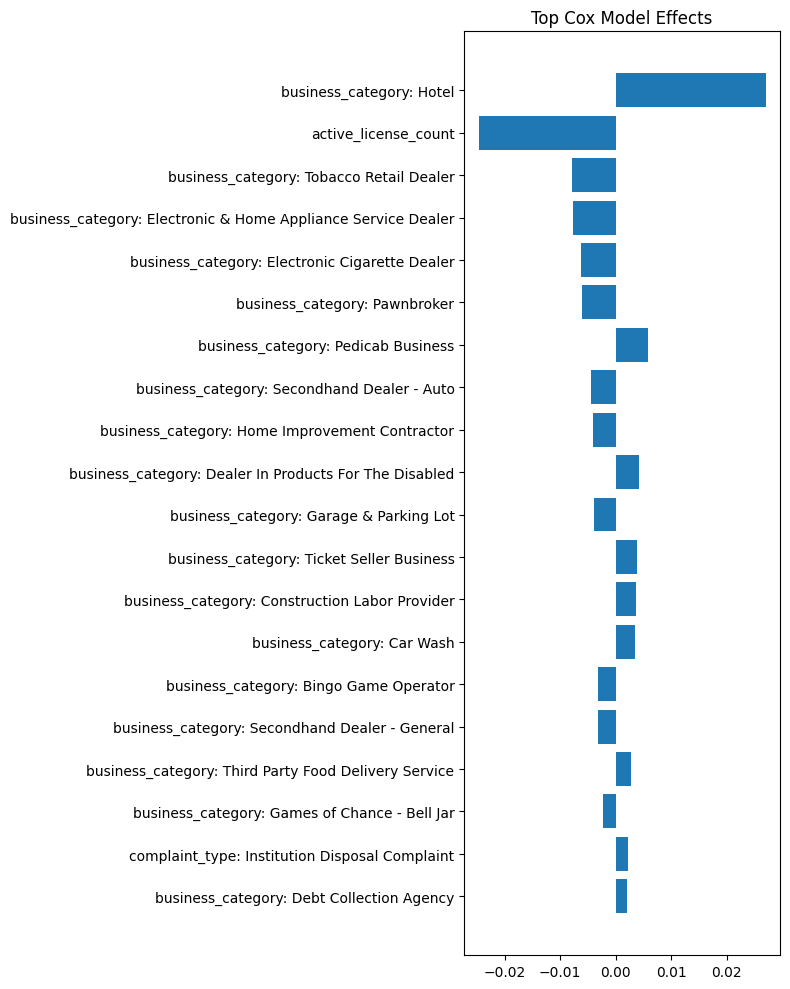

In [79]:
top = summary.head(20)

plt.figure(figsize=(8,10))
plt.barh(top["feature_readable"], top["coef"])
plt.title("Top Cox Model Effects")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

### 17. Standard Cox Model for survival probability prediction

Fits a simplified Cox model with fixed business features to estimate survival probabilities.

In [82]:
from lifelines import CoxPHFitter

We collapse the monthly panel into one row per business, where `duration_months` is the total time the business was observed open and `event` indicates whether it closed before the dataset ended. We use fixed features from the first observed month and estimate how those baseline characteristics related to how long the business survives.

In [83]:
business_df = joined.sort_values(["business_id", "month"]).copy()

# Duration = last observed month since first license
business_duration = (
    business_df.groupby("business_id")["months_since_first_license"]
    .max()
    .rename("duration_months")
)

# Event = 1 if the business disappears before the final month in the dataset, else 0
last_month_overall = business_df["month"].max()

business_event = (
    business_df.groupby("business_id")["month"]
    .max()
    .lt(last_month_overall)
    .astype(int)
    .rename("event")
)

# Use the first observed row for fixed business characteristics
business_features = (
    business_df.sort_values(["business_id", "month"])
    .groupby("business_id")
    .first()
    .reset_index()
)

# Merge duration and event
coxph_df = business_features.merge(
    business_duration.reset_index(),
    on="business_id",
    how="left"
).merge(
    business_event.reset_index(),
    on="business_id",
    how="left"
)

print("Business-level dataset shape:", coxph_df.shape)
coxph_df.head()

Business-level dataset shape: (18546, 238)


,business_id,month,active_license_count,business_category_0,business_category_1,business_category_2,business_category_3,business_category_4,business_category_5,business_category_6,...,complaint_type_176,open,months_since_first_license,location_cluster,business_category_sum,complaint_sum,location_cluster_lat,location_cluster_lng,duration_months,event
0,BA-1007652-2022,2025-05-01,1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,1,0,24,1.0,2.0,40.746573,-73.895733,21,1
1,BA-1010960-2022,2004-02-01,1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,1,0,24,1.0,0.0,40.746573,-73.895733,285,1
2,BA-1010972-2022,2011-07-01,1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,1,0,11,1.0,0.0,40.706592,-73.795619,187,1
3,BA-1010979-2022,2002-11-01,1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,1,0,11,1.0,0.0,40.706592,-73.795619,291,1
4,BA-1010980-2022,2014-01-01,1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,1,0,9,1.0,0.0,40.748799,-73.978687,107,1


In [84]:
coxph_df = coxph_df.drop(
    columns=[
        "month",
        "open",
        "business_category_sum",
        "complaint_sum",
        "total_311",
        "months_since_first_license",
        "location_cluster",
    ],
    errors="ignore",
).copy()

In [85]:
exclude_cols = ["business_id", "duration_months", "event"]

coxph_feature_cols = [c for c in coxph_df.columns if c not in exclude_cols]

print("Number of candidate CoxPH features:", len(coxph_feature_cols))
print(coxph_feature_cols[:20])

Number of candidate CoxPH features: 228
['active_license_count', 'business_category_0', 'business_category_1', 'business_category_2', 'business_category_3', 'business_category_4', 'business_category_5', 'business_category_6', 'business_category_7', 'business_category_8', 'business_category_9', 'business_category_10', 'business_category_11', 'business_category_12', 'business_category_13', 'business_category_14', 'business_category_15', 'business_category_16', 'business_category_17', 'business_category_18']


In [86]:
X_business = coxph_df[coxph_feature_cols].copy()

selector_ph = VarianceThreshold(threshold=1e-8)
X_business_reduced = selector_ph.fit_transform(X_business)

kept_cols_ph = X_business.columns[selector_ph.get_support()].tolist()
dropped_low_variance_ph = [c for c in X_business.columns if c not in kept_cols_ph]

print("Kept features:", len(kept_cols_ph))
print("Dropped near-constant features:", len(dropped_low_variance_ph))

if dropped_low_variance_ph:
    print("Example dropped columns:", dropped_low_variance_ph[:20])

Kept features: 178
Dropped near-constant features: 50
Example dropped columns: ['business_category_16', 'business_category_19', 'business_category_26', 'business_category_31', 'business_category_38', 'business_category_39', 'business_category_44', 'business_category_47', 'complaint_type_0', 'complaint_type_5', 'complaint_type_9', 'complaint_type_10', 'complaint_type_18', 'complaint_type_20', 'complaint_type_22', 'complaint_type_25', 'complaint_type_26', 'complaint_type_33', 'complaint_type_35', 'complaint_type_37']


In [87]:
scaler_ph = StandardScaler()

X_business_scaled = pd.DataFrame(
    scaler_ph.fit_transform(coxph_df[kept_cols_ph]),
    columns=kept_cols_ph,
    index=coxph_df.index,
)

In [88]:
coxph_model_df = pd.concat(
    [
        coxph_df[["business_id", "duration_months", "event"]],
        X_business_scaled
    ],
    axis=1,
).copy()

print("CoxPH modeling dataset shape:", coxph_model_df.shape)
coxph_model_df.head()

CoxPH modeling dataset shape: (18546, 181)


,business_id,duration_months,event,active_license_count,business_category_0,business_category_1,business_category_2,business_category_3,business_category_4,business_category_5,...,complaint_type_165,complaint_type_167,complaint_type_168,complaint_type_169,complaint_type_170,complaint_type_171,complaint_type_172,complaint_type_173,location_cluster_lat,location_cluster_lng
0,BA-1007652-2022,21,1,-0.180981,-0.028451,-0.019431,-0.082043,-0.010385,-0.028451,-0.187521,...,-0.007343,-0.01799,-0.036253,-0.014423,-0.04172,-0.019909,-0.010385,-0.046847,0.038614,0.013690
1,BA-1010960-2022,285,1,-0.180981,-0.028451,-0.019431,-0.082043,-0.010385,-0.028451,-0.187521,...,-0.007343,-0.01799,-0.036253,-0.014423,-0.04172,-0.019909,-0.010385,-0.046847,0.038614,0.013690
2,BA-1010972-2022,187,1,-0.180981,-0.028451,-0.019431,-0.082043,-0.010385,-0.028451,-0.187521,...,-0.007343,-0.01799,-0.036253,-0.014423,-0.04172,-0.019909,-0.010385,-0.046847,-0.017370,0.059970
3,BA-1010979-2022,291,1,-0.180981,-0.028451,-0.019431,-0.082043,-0.010385,-0.028451,-0.187521,...,-0.007343,-0.01799,-0.036253,-0.014423,-0.04172,-0.019909,-0.010385,-0.046847,-0.017370,0.059970
4,BA-1010980-2022,107,1,-0.180981,-0.028451,-0.019431,-0.082043,-0.010385,-0.028451,-0.187521,...,-0.007343,-0.01799,-0.036253,-0.014423,-0.04172,-0.019909,-0.010385,-0.046847,0.041730,-0.024656


In [89]:
cph = CoxPHFitter(penalizer=0.1)

cph.fit(
    coxph_model_df.drop(columns=["business_id"], errors="ignore"),
    duration_col="duration_months",
    event_col="event",
    show_progress=True,
)

cph.print_summary()

Iteration 1: norm_delta = 1.13e+00, step_size = 0.9500, log_lik = -163730.09549, newton_decrement = 4.06e+03, seconds_since_start = 0.3
Iteration 2: norm_delta = 3.07e+01, step_size = 0.9500, log_lik = -206318.07730, newton_decrement = 1.25e+06, seconds_since_start = 0.5
Iteration 3: norm_delta = 4.20e+01, step_size = 0.0950, log_lik = -222651.23491, newton_decrement = 1.76e+06, seconds_since_start = 0.8
Iteration 4: norm_delta = 5.09e+00, step_size = 0.0121, log_lik = -183450.89086, newton_decrement = 5.06e+04, seconds_since_start = 1.1
Iteration 5: norm_delta = 5.05e+00, step_size = 0.0039, log_lik = -183061.71835, newton_decrement = 4.85e+04, seconds_since_start = 1.3
Iteration 6: norm_delta = 5.03e+00, step_size = 0.0016, log_lik = -182903.86864, newton_decrement = 4.77e+04, seconds_since_start = 1.6
Iteration 7: norm_delta = 5.02e+00, step_size = 0.0007, log_lik = -182838.24046, newton_decrement = 4.74e+04, seconds_since_start = 1.8
Iteration 8: norm_delta = 5.02e+00, step_size = 

<lifelines.CoxPHFitter: fitted with 18546 total observations, 1 right-censored observations>
             duration col = 'duration_months'
                event col = 'event'
                penalizer = 0.1
                 l1 ratio = 0.0
      baseline estimation = breslow
   number of observations = 18546
number of events observed = 18545
   partial log-likelihood = -182791.25
         time fit was run = 2026-03-09 07:40:48 UTC

---
                      coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                             
active_license_count  0.00      1.00      0.01           -0.02            0.02                0.98                1.02
business_category_0  -0.03      0.97      0.01           -0.04           -0.02                0.96                0.98
business_category_1   0.03      1.03      0.01            0.01            0.04                1.01                1.04
business_category_2   0.06      1.06      0.01            0.05            0.08                1.05                1.08
business_category_3  -0.01      0.99      0.01           -0.02            0.00                0.98                1.00
business_category_4   0.09      1.10      0.01            0.08            0.11                1.08                1.12
business_category_5   0.04      1.05      0.01            0.03            0.06                1.03                1.06
business_category_6   0.03      1.03      0.01            0.01            0.04                1.01                1.04
business_category_7  -0.03      0.97      0.01           -0.05           -0.01                0.95                0.99
business_category_8   0.13      1.14      0.01            0.12            0.15                1.12                1.16
business_category_9   0.10      1.10      0.01            0.08            0.12                1.08                1.13
business_category_10 -0.01      0.99      0.01           -0.02            0.01                0.98                1.01
business_category_11 -0.02      0.98      0.00           -0.03           -0.01                0.97                0.99
business_category_12 -0.00      1.00      0.00           -0.01            0.01                0.99                1.01
business_category_13 -0.02      0.98      0.01           -0.03           -0.01                0.97                0.99
business_category_14 -0.02      0.98      0.01           -0.03           -0.01                0.97                0.99
business_category_15 -0.04      0.96      0.01           -0.06           -0.03                0.94                0.97
business_category_17  0.01      1.01      0.01           -0.01            0.02                0.99                1.02
business_category_18 -0.03      0.97      0.01           -0.06           -0.01                0.94                0.99
business_category_20 -0.01      0.99      0.01           -0.02            0.00                0.98                1.00
business_category_21 -0.12      0.88      0.02           -0.17           -0.08                0.84                0.92
business_category_22  0.03      1.03      0.01            0.01            0.04                1.01                1.04
business_category_23  0.00      1.00      0.01           -0.01            0.02                0.99                1.02
business_category_24  0.05      1.05      0.01            0.04            0.06                1.04                1.07
business_category_25 -0.01      0.99      0.01           -0.02            0.00                0.98                1.00
business_category_27 -0.01      0.99      0.01           -0.02            0.01                0.98                1.01
business_category_28 -0.03      0.97      0.01           -0.04           -0.01                0.96                0.99
business_category_29  0.11      1.11      0.01            0.09            0.12                1.10            

In [109]:
cph_summary = cph.summary.copy()
cph_summary["feature_readable"] = cph_summary.index.map(translate_feature_name)
cph_summary["abs_coef"] = cph_summary["coef"].abs()

cph_summary = cph_summary.sort_values("abs_coef", ascending=False)
cph_summary[["feature_readable", "coef", "exp(coef)", "p"]].head(5)

,feature_readable,coef,exp(coef),p
covariate,,,,
complaint_type_78,complaint_type: Illegal Parking,-1.358154,0.257135,0.000000e+00
complaint_type_146,complaint_type: Street Sign - Damaged,-0.633486,0.530739,6.966838e-164
complaint_type_73,complaint_type: Homeless Person Assistance,-0.564316,0.568749,7.690526e-131
complaint_type_58,complaint_type: FLOORING/STAIRS,-0.439466,0.644381,1.013364e-84
complaint_type_114,complaint_type: Outdoor Dining,-0.411000,0.662987,4.176662e-70


Creates a hypothetical business profile to test the Cox survival model.

In [91]:
hypo = coxph_model_df.iloc[[0]].copy()

business_cat_cols = [c for c in hypo.columns if c.startswith("business_category_")]
complaint_cols = [c for c in hypo.columns if c.startswith("complaint_type_")]

# Example edits
if business_cat_cols:
    hypo.loc[:, business_cat_cols] = 0
    if "business_category_21" in hypo.columns: # Hotel
        hypo["business_category_21"] = 1

if complaint_cols:
    hypo.loc[:, complaint_cols] = 0
    if "complaint_type_0" in hypo.columns:
        hypo["complaint_type_0"] = 2
    if "complaint_type_1" in hypo.columns:
        hypo["complaint_type_1"] = 1

if "active_license_count" in hypo.columns:
    hypo["active_license_count"] = 1

hypo

,business_id,duration_months,event,active_license_count,business_category_0,business_category_1,business_category_2,business_category_3,business_category_4,business_category_5,...,complaint_type_165,complaint_type_167,complaint_type_168,complaint_type_169,complaint_type_170,complaint_type_171,complaint_type_172,complaint_type_173,location_cluster_lat,location_cluster_lng
0,BA-1007652-2022,21,1,1,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.038614,0.01369


In [92]:
hypo_features = hypo.drop(columns=["business_id", "duration_months", "event"], errors="ignore")

# Predict survival function
surv_fn = cph.predict_survival_function(hypo_features, times=[12, 36, 60, 120])

surv_fn

,0
12.0,0.999924
36.0,0.956082
60.0,0.875188
120.0,0.658599


In [93]:
p_1yr = float(surv_fn.loc[12].iloc[0])
p_3yr = float(surv_fn.loc[36].iloc[0])
p_5yr = float(surv_fn.loc[60].iloc[0])
p_10yr = float(surv_fn.loc[120].iloc[0])

print(f"P(open at least 1 year):  {p_1yr:.4f}")
print(f"P(open at least 3 years): {p_3yr:.4f}")
print(f"P(open at least 5 years): {p_5yr:.4f}")
print(f"P(open at least 10 years): {p_10yr:.4f}")

P(open at least 1 year):  0.9999
P(open at least 3 years): 0.9561
P(open at least 5 years): 0.8752
P(open at least 10 years): 0.6586


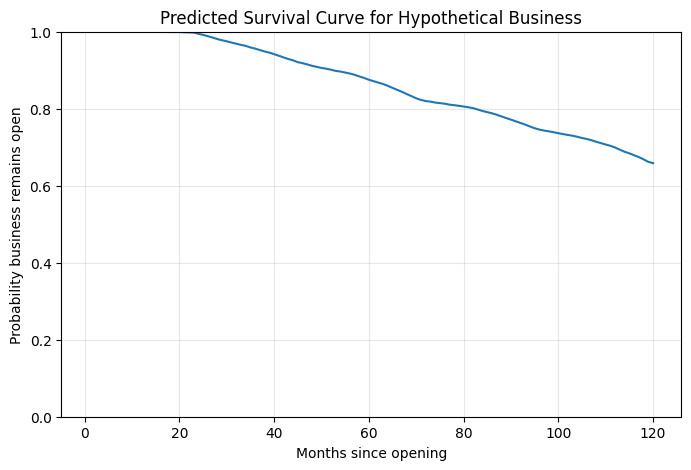

In [94]:
times = np.arange(1, 121)

surv_curve = cph.predict_survival_function(hypo_features, times=times)

plt.figure(figsize=(8, 5))
plt.plot(times, surv_curve.iloc[:, 0])
plt.xlabel("Months since opening")
plt.ylabel("Probability business remains open")
plt.title("Predicted Survival Curve for Hypothetical Business")
plt.ylim(0, 1)
plt.grid(True, alpha=0.3)
plt.show()

In [95]:
with open("/content/drive/MyDrive/coxph_model.pkl", "wb") as f:
    pickle.dump(cph, f)

with open("/content/drive/MyDrive/coxph_scaler.pkl", "wb") as f:
    pickle.dump(scaler_ph, f)

with open("/content/drive/MyDrive/coxph_kept_columns.pkl", "wb") as f:
    pickle.dump(kept_cols_ph, f)

print("Saved standard CoxPH prediction artifacts to Drive.")

Saved standard CoxPH prediction artifacts to Drive.
